K MEANS CLUSTERING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
x, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)


In [5]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
df.head()

,feature1,feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [6]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [7]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [8]:
inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

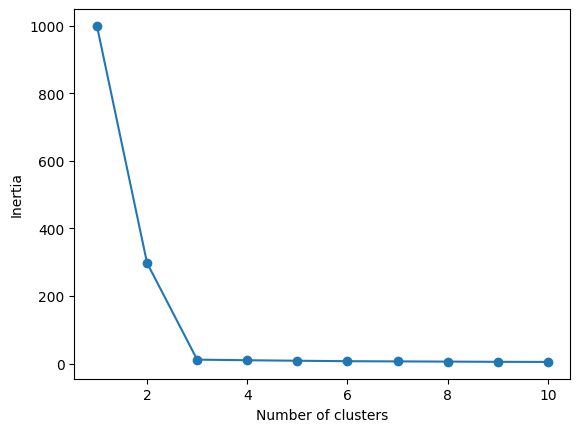

In [9]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()
#

In [10]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit(x_scaled)

In [19]:
df['cluster'] = cluster_labels.fit_predict(x_scaled)
df.head()

,feature1,feature2,cluster
0,-6.190063,-7.302015,1
1,3.021747,1.940593,0
2,5.953761,1.488191,0
3,-2.744463,8.136177,2
4,5.360607,1.728324,0


<Axes: xlabel='feature1', ylabel='feature2'>

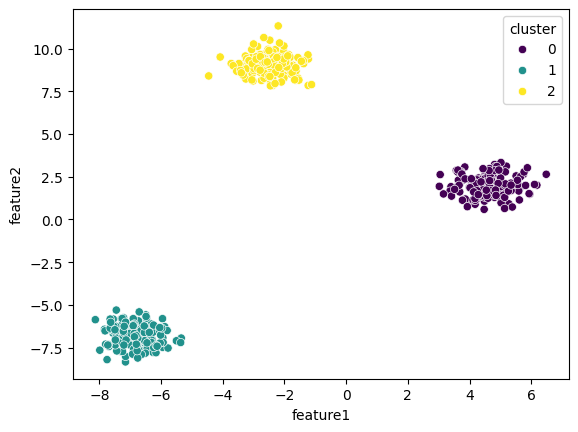

In [20]:
sns.scatterplot(x=df['feature1'],
                y=df['feature2'],
                hue='cluster',
                data=df,
                palette='viridis')


DB SCAN

In [23]:
from sklearn.datasets import make_moons #generate cluster

In [24]:
x, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [25]:
from sklearn.cluster import DBSCAN, KMeans

In [26]:
df = pd.DataFrame(x, columns=['feature1', 'feature2'])
df.head()

,feature1,feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [27]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [28]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)

In [30]:
df['kmeans_cluster'] = kmeans_labels


<Axes: xlabel='feature1', ylabel='feature2'>

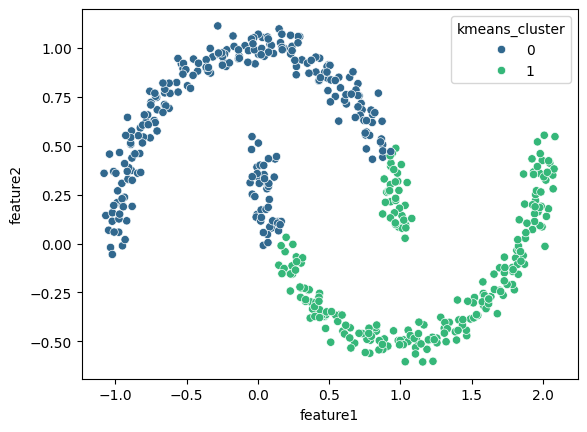

In [31]:
sns.scatterplot(x=df['feature1'],
                y=df['feature2'],
                hue=df['kmeans_cluster'],
                data=df,
                palette='viridis')

In [34]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

In [35]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='feature1', ylabel='feature2'>

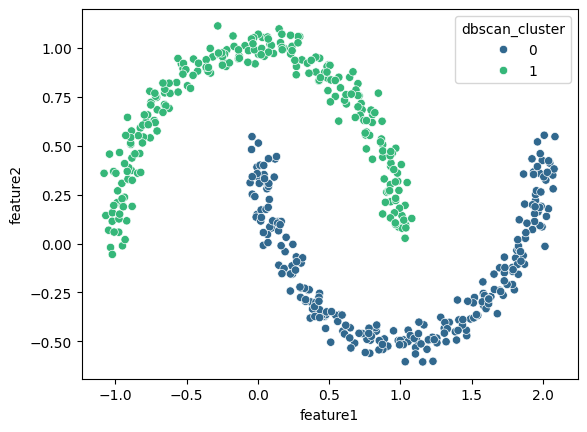

In [36]:
sns.scatterplot(x=df['feature1'],
                y=df['feature2'],
                hue=df['dbscan_cluster'],
                data=df,
                palette='viridis')
#